In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("optimized_waste_management_data.csv")

In [13]:
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [14]:
df.describe()

,waste_volume,organic_waste,recyclable_waste,hazardous_waste,landfill_capacity_used,recycling_rate
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,50.158919,30.135010,15.062491,4.961355,54.862266,44.393060
std,8.771361,7.635123,4.029920,1.019074,5.024692,5.267204
min,28.810000,10.480000,4.230000,1.990000,38.310000,29.140000
25%,43.660000,23.740000,11.730000,4.270000,51.570000,40.790000
50%,50.980000,30.040000,15.020000,4.970000,54.810000,44.310000
75%,56.590000,36.650000,18.330000,5.620000,58.190000,48.140000
max,70.830000,48.540000,25.160000,8.240000,71.030000,59.960000


In [15]:
df.shape

(1461, 8)

In [16]:
df.isna().count()

date                      1461
waste_volume              1461
organic_waste             1461
recyclable_waste          1461
hazardous_waste           1461
collection_frequency      1461
landfill_capacity_used    1461
recycling_rate            1461
dtype: int64

In [17]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

In [18]:
#Extract feature to predict
#We only use the waste column for forecasting
waste_data=df[['waste_volume']]

In [19]:
#Normalize the data=(Neural netowrks work better when data values are scaled between 0 and 1)
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)

In [20]:
#Convert data into sequences=RNN reguires Sequential input
#Ex:previous 10 days->predict next day
def create_sequences(data,seq_length):
    X=[]
    Y=[]
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        Y.append(data[i+seq_length])
    return np.array(X),np.array(Y)

In [ ]:
#Create time Sequences
sequence_length=10
X,y=create_sequences(scaled_data,sequence_length)


In [22]:
print(X.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


In [23]:
#Build the RNN model
#Architecture: Input -> RNN Layer -> Dense Output
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))
model.add(Dense(1))

c:\Users\Nihal - Pooju\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Split
split=int(0.8*len(X))
X_train=X[:split]
X_test=X[split:]

y_train=y[:split]
y_test=y[split:]

#Train the model
history=model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0416 - val_loss: 0.0171
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0105 - val_loss: 0.0160
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0097 - val_loss: 0.0117
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0096 - val_loss: 0.0110
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0096 - val_loss: 0.0119
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 - val_loss: 0.0114
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - val_loss: 0.0113
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 - val_loss: 0.0118
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0100 - val_loss: 0.0112
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - val_loss: 0.0182
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0102 - val_loss: 0.0119
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 - val_lo

In [28]:
loss=model.evaluate(X_test,y_test)
print("Test Loss:",loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 
Test Loss: 0.009478660300374031


In [29]:
# Make Preictions
predictions=model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [30]:
predictions=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))

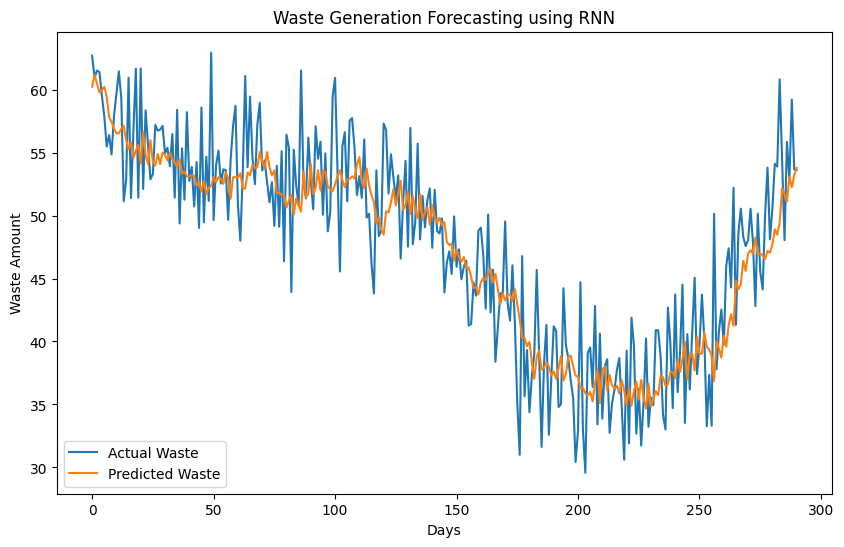

In [32]:
# Plot Predictions vs Actual Values
plt.figure(figsize=(10,6))
plt.plot(y_test_actual,label="Actual Waste")
plt.plot(predictions,label="Predicted Waste")
plt.title("Waste Generation Forecasting using RNN")
plt.xlabel('Days')
plt.ylabel('Waste Amount')
plt.legend()
plt.show()
# If two lines are close => Good Model